# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [57]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [59]:
# mostrar las primeras 5 filas de plans
print("=== PRIMERAS 5 FILAS DE PLANS ===")
plans.head()

=== PRIMERAS 5 FILAS DE PLANS ===


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [60]:
# mostrar las primeras 5 filas de users
print("=== PRIMERAS 5 FILAS DE USERS ===")
users.head()

=== PRIMERAS 5 FILAS DE USERS ===


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [61]:
# mostrar las primeras 5 filas de usage
print("=== PRIMERAS 5 FILAS DE USAGE ===")
usage.head()

=== PRIMERAS 5 FILAS DE USAGE ===


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [62]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", ...)
print("usage", ...)

plans (2, 8)
users Ellipsis
usage Ellipsis


In [63]:
# inspección de plans con .info()

print("=== DATASET PLANS ===")
print("Forma (filas, columnas):", plans.shape)
print("\nInformación detallada:")
plans.info()
print("\nValores nulos por columna:")
print(plans.isnull().sum())

print("\n" + "="*50 + "\n")

=== DATASET PLANS ===
Forma (filas, columnas): (2, 8)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes

Valores nulos por columna:
plan_name            0
messages_included    0
gb_per_month         0
minutes_included     0
usd_monthly_pay      0
usd_per_gb           0
usd_per_message      0
usd_per_minute       0
dtype: int64




In [64]:
# inspección de users con .info()

print("=== DATASET USERS ===")
print("Forma (filas, columnas):", users.shape)
print("\nInformación detallada:")
users.info()
print("\nValores nulos por columna:")
print(users.isnull().sum())

print("\n" + "="*50 + "\n")

=== DATASET USERS ===
Forma (filas, columnas): (4000, 8)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB

Valores nulos por columna:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64




In [65]:
# inspección de usage con .info()

print("=== DATASET USAGE ===")
print("Forma (filas, columnas):", usage.shape)
print("\nInformación detallada:")
usage.info()
print("\nValores nulos por columna:")
print(usage.isnull().sum())

=== DATASET USAGE ===
Forma (filas, columnas): (40000, 6)

Información detallada:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB

Valores nulos por columna:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [66]:
# Análisis completo de valores faltantes
print("=== RESUMEN DE VALORES FALTANTES POR DATASET ===\n")

datasets = {'PLANS': plans, 'USERS': users, 'USAGE': usage}

for name, df in datasets.items():
    print(f"--- {name} ---")
    print(f"Forma: {df.shape}")
    
    # Conteo de nulos
    null_counts = df.isnull().sum()
    
    # Proporción de nulos
    null_props = (df.isnull().sum() / len(df) * 100).round(2)
    
    # Crear resumen
    null_summary = pd.DataFrame({
        'Valores_Nulos': null_counts,
        'Porcentaje': null_props
    })
    
    print(null_summary[null_summary['Valores_Nulos'] > 0])
    print(f"Total de columnas con nulos: {(null_counts > 0).sum()}")
    print("="*40 + "\n")

=== RESUMEN DE VALORES FALTANTES POR DATASET ===

--- PLANS ---
Forma: (2, 8)
Empty DataFrame
Columns: [Valores_Nulos, Porcentaje]
Index: []
Total de columnas con nulos: 0

--- USERS ---
Forma: (4000, 8)
            Valores_Nulos  Porcentaje
city                  469       11.72
churn_date           3534       88.35
Total de columnas con nulos: 2

--- USAGE ---
Forma: (40000, 6)
          Valores_Nulos  Porcentaje
date                 50        0.12
duration          22076       55.19
length            17896       44.74
Total de columnas con nulos: 3



In [67]:
# cantidad de nulos para usage

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- 
- Dentro del data set de USERS existen datos faltantes en dos columnas, ciudad y la taza de abandono del servicio "CHURN" las cuales ambas son manejables ya que el 11.72% en ciudades es manejable y el 88.35% en churn representa simplemente que la mayoria de los clientes se mantienen activos, usariamos el porcentaje restante seguramente mas adelante para entender las razones del porque dejaron de ser clientes.
- 
Por otro lado en el dataset de USAGE tenemos datos faltantes en tres columnas, la primera que es la fecha de inicio de relacion como clientes es manejable ya que es un % muy bajo del 0.12%, las restantes dos columnas son MbD ( Missing by Design) lo cual representa que no son valores nulos por error de captura de datos si no por el diseño del mismo data set, eso ya lo explicare mas adelante para no extenderme demasiado aqui.

 
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En algunos casos imputaremos los pocos datos faltates como la fecha en USAGE y la ciudad en USERS, los restantes como length y messages en USAGE sera ignorar ya que es por MbD

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [68]:
# explorar columnas numéricas de users
# Explorar columnas numéricas de users
print("=== RESUMEN ESTADÍSTICO DE USERS ===")
users.describe()

=== RESUMEN ESTADÍSTICO DE USERS ===


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- En esta columna observo parametros normales ya que al ser valores identificativos al expresarse de manera cuantitativos suelen arrojar como los que se muestran, lo que se rescata de aqui es son cuatro mil registros al igual que en l columna edades y tambien noto que los registros van desde el numero 10,000 de usuario al 14,000, puedo pensar que los diez mil anteriores son de años anteriores tambien.
  
- La columna `age` ...
- Esta columna nos dice que la edad promedio es de 47 años por ejemplo en los usuarios clientes, tambien hay datos sentinel como el minumo que al haber un faltante el dataset lo relleno con -999 lo cual afecta directamente el prmedio de edades y la fiabilidad de usar la columna asi como esta para sacar datos futuros, primero habra que imputar esos -999 que represetna segun mis lineas de codigo anterior un 11.72% de los datos totales de la columna "Age" o sea que no es un gran problema realmente.

In [69]:

# Explorar columnas numéricas de usage
print("=== RESUMEN ESTADÍSTICO DE USAGE ===")
usage.describe()

=== RESUMEN ESTADÍSTICO DE USAGE ===


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas se ven solidas con los datos que contienen, hay ligeras variaciones por posibles datos faltantes pero son demasiado pocos para ser realmente alarmantes, se puede corregir emputando en acciones posteriores

In [70]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']



for col in columnas_user:
    print(f"=== COLUMNA: {col.upper()} ===")
    print(f"Valores únicos: {users[col].nunique()}")
    print(f"Valores únicos:")
    print(users[col].unique())
    print(f"\nDistribución de frecuencias:")
    print(users[col].value_counts())
    print("="*40 + "\n")




=== COLUMNA: CITY ===
Valores únicos: 7
Valores únicos:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Distribución de frecuencias:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

=== COLUMNA: PLAN ===
Valores únicos: 2
Valores únicos:
['Basico' 'Premium']

Distribución de frecuencias:
Basico     2595
Premium    1405
Name: plan, dtype: int64



- La columna `city` ... 7 valores unicos incluyendo un "varios" que se muestra como un signo de interogacion.
- La columna `plan` ... solo 2 valores unicos que son el plan basico y el premium basicamente.

In [71]:
# explorar columna categórica de usage
columnas_usage = ['type']  

for col in columnas_usage:
    print(f"=== COLUMNA: {col.upper()} ===")
    print(f"Valores únicos: {usage[col].nunique()}")
    print(f"Valores únicos:")
    print(usage[col].unique())
    print(f"\nDistribución de frecuencias:")
    print(usage[col].value_counts())
    print("="*40 + "\n")

=== COLUMNA: TYPE ===
Valores únicos: 2
Valores únicos:
['call' 'text']

Distribución de frecuencias:
text    22092
call    17908
Name: type, dtype: int64



- La columna `type` ... tambien solo hay dos valores unicos que serian las llamadas y los mensajes de texto


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Parece que en la columna de ciudades en el data set de usuarios hay algunos valores no definidos que se agruparon con una sub-categoria de "?"
- 
- ¿Qué acción tomarías?  podriamos imputar esos pocos valores para estandarizarlos a los demas datos que muestran mucho mas constancia y confianza en sus grabaciones

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [72]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [73]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [74]:
# Revisar los años presentes en `reg_date` de users
print("=== AÑOS EN REG_DATE ===")
years_reg = users['reg_date'].dt.year
print("Años únicos:", sorted(years_reg.unique()))
print("\nDistribución por año:")
print(years_reg.value_counts().sort_index())

=== AÑOS EN REG_DATE ===
Años únicos: [2022, 2023, 2024, 2026]

Distribución por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Veo que hay un promedio muy estable de registros entre el 2022 y el 2024, despues me esta faltando el 2025 y se brinca hasta el 2026 con pocos registros "40" por estar en curso actualmente este año

In [75]:
# Revisar los años presentes en `date` de usage

print("=== AÑOS EN DATE (USAGE) ===")
years_usage = usage['date'].dt.year
print("Años únicos:", sorted(years_usage.unique()))
print("\nDistribución por año:")
print(years_usage.value_counts().sort_index())

=== AÑOS EN DATE (USAGE) ===
Años únicos: [2024.0, nan]

Distribución por año:
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Veo que todos los registros corresponden al año 2024 en esta columna del dataset usage 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Asi es, aparecen datos en el año 2026 el cual es un año futuro por lo que no deberia entrar aun en nuestros analisis
- ¿Qué harías con ellas?
- Cambiarlo de año para incluirlo dentro de los años que si buscamos analizar principalmente el 2024 seria la opcion mas viable ya que son pocos los registros del 2026, 40 para sr exactos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [76]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'][users['age'] != -999].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [77]:
# Reemplazar "?" por "NA" en la columna city
users['city'] = users['city'].replace('?', 'NA')

# Verificar los cambios
print("=== VERIFICACIÓN DE LIMPIEZA EN CITY ===")
print("Valores únicos después de la limpieza:")
print(users['city'].value_counts())
print(f"\nTotal de ciudades 'NA': {(users['city'] == 'NA').sum()}")


=== VERIFICACIÓN DE LIMPIEZA EN CITY ===
Valores únicos después de la limpieza:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
NA           96
Name: city, dtype: int64

Total de ciudades 'NA': 96


In [78]:

# Identificar y corregir fechas futuras en reg_date
print("=== CORRECCIÓN DE FECHAS FUTURAS ===")
print(f"Registros con año 2026: {(users['reg_date'].dt.year == 2026).sum()}")

# Reemplazar 2026 por 2024 (asumiendo error de digitación)
mask_futuro = users['reg_date'].dt.year == 2026
users.loc[mask_futuro, 'reg_date'] = users.loc[mask_futuro, 'reg_date'].apply(
    lambda x: x.replace(year=2024)
)

# Verificar corrección
print("\nDespués de la corrección:")
print("Años únicos:", sorted(users['reg_date'].dt.year.unique()))


=== CORRECCIÓN DE FECHAS FUTURAS ===
Registros con año 2026: 40

Después de la corrección:
Años únicos: [2022, 2023, 2024]


In [79]:
# Resumen final de limpieza
print("=== RESUMEN FINAL DE LIMPIEZA ===")
print("\n1. EDAD:")
print(f"   - Valores -999 reemplazados por mediana: {age_mediana:.1f}")
print(f"   - Rango actual: {users['age'].min():.0f} - {users['age'].max():.0f}")

print("\n2. CIUDADES:")
print(f"   - Registros 'NA': {(users['city'] == 'NA').sum()}")

print("\n3. FECHAS:")
print(f"   - Años en reg_date: {sorted(users['reg_date'].dt.year.unique())}")
print(f"   - Rango: {users['reg_date'].min()} a {users['reg_date'].max()}")

=== RESUMEN FINAL DE LIMPIEZA ===

1. EDAD:
   - Valores -999 reemplazados por mediana: 48.0
   - Rango actual: 18 - 79

2. CIUDADES:
   - Registros 'NA': 96

3. FECHAS:
   - Años en reg_date: [2022, 2023, 2024]
   - Rango: 2022-01-01 00:00:00 a 2024-12-31 00:00:00


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [80]:
# Verificación MAR en usage (Missing At Random) para duration

print("=== ANÁLISIS DE NULOS EN DURATION POR TYPE ===")
duration_analysis = usage.groupby('type')['duration'].agg(['count', lambda x: x.isna().sum()])
print(duration_analysis)


=== ANÁLISIS DE NULOS EN DURATION POR TYPE ===
      count  <lambda_0>
type                   
call  17908         0.0
text     16     22076.0


In [81]:
# Verificación MAR en usage (Missing At Random) para length

print("=== ANÁLISIS DE NULOS EN LENGTH POR TYPE ===")
length_analysis = usage.groupby('type')['length'].agg(['count', lambda x: x.isna().sum()])
print(length_analysis)

=== ANÁLISIS DE NULOS EN LENGTH POR TYPE ===
      count  <lambda_0>
type                   
call     12     17896.0
text  22092         0.0


In [82]:
ambos_valores = usage[(usage['duration'].notna()) & (usage['length'].notna())]
print (ambos_valores)

          id  user_id  type                          date  duration  length
1414    1415    10399  text 2024-01-07 09:33:51.260781519    120.00    65.0
1824    1825    12936  text 2024-01-09 06:05:28.868221705    120.00    40.0
1932    1933    10189  text 2024-01-09 17:49:13.603840096    120.00    69.0
2070    2071    13139  call 2024-01-10 08:48:27.432685817      1.68  1490.0
2972    2973    10085  text 2024-01-14 10:46:02.169054226    120.00    68.0
5272    5273    11750  call 2024-01-24 20:33:12.649816245      3.78  1490.0
10614  10615    13855  call 2024-02-18 00:42:33.183829595      0.53  1490.0
11456  11457    13325  text 2024-02-21 20:09:09.733743343    120.00    23.0
12692  12693    12263  call 2024-02-27 10:23:08.374709367      1.80  1490.0
16702  16703    10484  text 2024-03-16 13:52:57.169429235    120.00    48.0
16910  16911    12099  call 2024-03-17 12:28:18.882472061      3.29  1490.0
20727  20728    10599  call 2024-04-03 19:00:30.510762768      0.40  1490.0
20778  20779

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- Efectivamente, es un caso clásico de Missing At Random (MAR) por diseño del sistema.

Mi observación sobre los pocos registros que tienen ambas variables es la siguiente:

Llamadas (call): Tienen duration pero no length (como debe ser)
Mensajes (text): Tienen length pero no duration (como debe ser)
Registros anómalos: Solo 28 registros tienen ambos valores
Y tienes razón al identificar que estos valores duplicados son errores de captura. Mirando los datos que me arroja el dataset:

Los mensajes con duration siempre tienen 120.00 (valor de relleno)
Las llamadas con length siempre tienen 1490.0 (valor de relleno)
Estos claramente son valores predeterminados que se insertaron por error durante la captura de datos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [83]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',        # Total de mensajes
    'is_call': 'sum',        # Total de llamadas  
    'duration': 'sum'        # Total de minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [84]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas', 
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [85]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [86]:
# Resumen estadístico de las columnas numéricas
# Seleccionar columnas numéricas relevantes
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Obtener resumen estadístico
user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [87]:
# Distribución porcentual del tipo de plan
plan_distribution = user_profile['plan'].value_counts(normalize=True) * 100
print("=== DISTRIBUCIÓN PORCENTUAL POR PLAN ===")
print(plan_distribution)
print("\n")

# Calcular percentiles por plan para las 4 variables
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
percentiles = [0.25, 0.5, 0.75, 0.9]  # 25%, 50%, 75%, 90%

print("=== PERCENTILES POR PLAN ===")
for columna in columnas_numericas:
    print(f"\n--- {columna.upper()} ---")
    percentiles_por_plan = user_profile.groupby('plan')[columna].quantile(percentiles).unstack()
    print(percentiles_por_plan)


=== DISTRIBUCIÓN PORCENTUAL POR PLAN ===
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


=== PERCENTILES POR PLAN ===

--- AGE ---
         0.25  0.50  0.75  0.90
plan                           
Basico   33.0  48.0  63.0  73.0
Premium  33.0  48.0  64.0  74.0

--- CANT_MENSAJES ---
         0.25  0.50  0.75  0.90
plan                           
Basico    4.0   5.0   7.0   9.0
Premium   4.0   5.0   7.0   9.0

--- CANT_LLAMADAS ---
         0.25  0.50  0.75  0.90
plan                           
Basico    3.0   4.0   6.0   7.0
Premium   3.0   4.0   6.0   7.0

--- CANT_MINUTOS_LLAMADA ---
            0.25    0.50     0.75    0.90
plan                                     
Basico   10.9125  19.535  30.8025  42.717
Premium  11.5900  20.640  32.5200  44.276


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

No handles with labels found to put in legend.


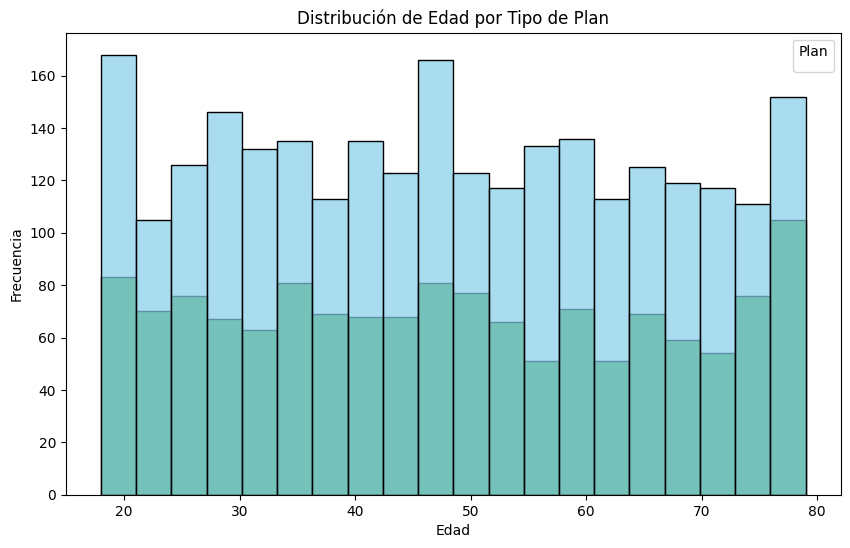

In [88]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=20, alpha=0.7)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

💡Insights: 
- Distribución ...

- No hay una tendencia clara entre edad y tipo de plan - ambos planes se distribuyen de manera similar a través de todas las edades
- Los usuarios de 20 años muestran una distribución equilibrada entre ambos planes
- Los usuarios mayores de 80 años efectivamente muestran una ligera preferencia por el plan Premium


Insights adicionales:

- La distribución de edad es simétrica para ambos planes
- El rango de edad más común está entre 30-65 años para ambos planes
- No existe segmentación por edad en la elección del plan

No handles with labels found to put in legend.


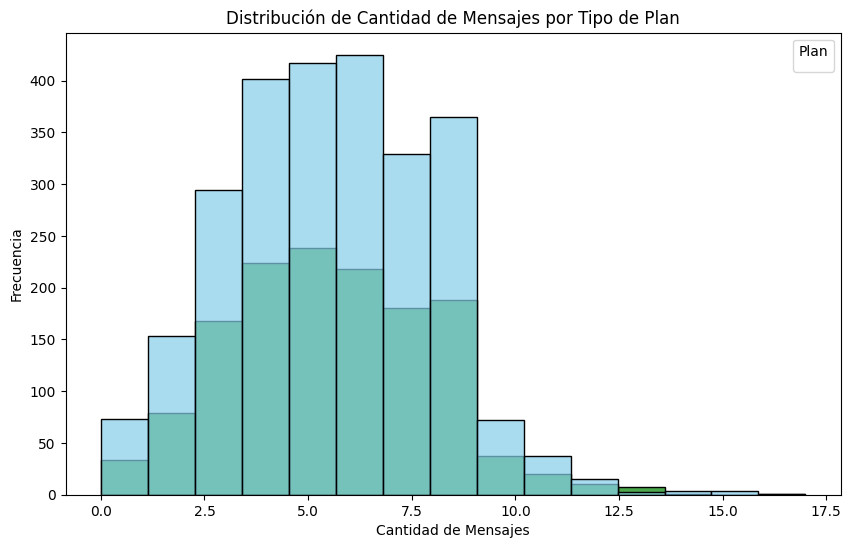

In [89]:

# Histograma para visualizar la cant_mensajes

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()



💡Insights: 

- Ambos planes (Básico y Premium) muestran comportamientos similares en el envío de mensajes
- La mayoría de usuarios envían entre 4-9 mensajes independientemente del plan
- Hay un sesgo hacia la derecha (right skew) después de los 10 mensajes, lo que indica que pocos usuarios son "heavy users" de mensajes


No handles with labels found to put in legend.


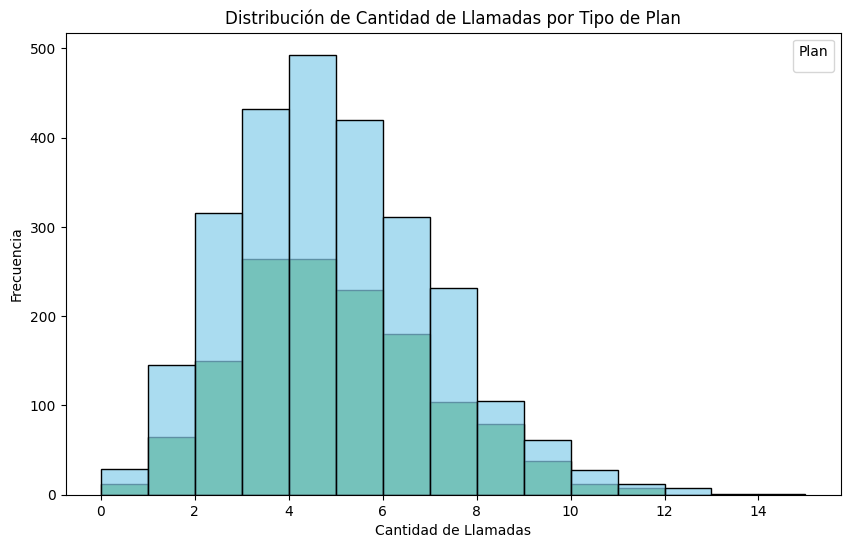

In [90]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()


💡Insights: 

Patrones observados:

- Pico principal: Entre 2-8 llamadas por usuario
- Distribución sesgada: Hacia la derecha después de 8 llamadas
- Usuarios "heavy callers": Muy pocos usuarios hacen más de 10 llamadas
  
Comparación con mensajes:

- Ambas variables (mensajes y llamadas) muestran distribuciones similares
- No hay diferencias significativas entre planes Básico y Premium
- La mayoría de usuarios tienen un comportamiento moderado en ambas métricas

No handles with labels found to put in legend.


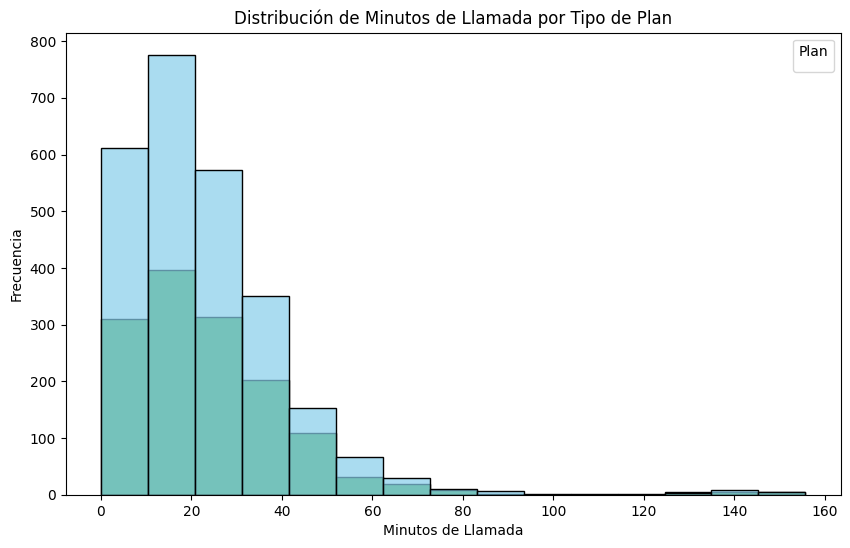

In [91]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=15, alpha=0.7)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Frecuencia')
plt.legend(title='Plan')
plt.show()

💡Insights: 

- Simetría entre planes: Al igual que los histogramas anteriores, se mantiene una distribución similar entre planes Básico y Premium
- Concentración en pocos minutos: La mayoría de usuarios oscilan entre 1-2 minutos de llamada
- Descenso abrupto: La gráfica desciende abruptamente a partir de los 40 minutos
- Diferencia notable: Los usuarios Premium muestran una mayor tendencia a mantener llamadas largas
- Límite natural: Muy pocos usuarios exceden la hora de llamada al mes
- Distribución sesgada: Hacia la derecha, similar a las variables anteriores

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

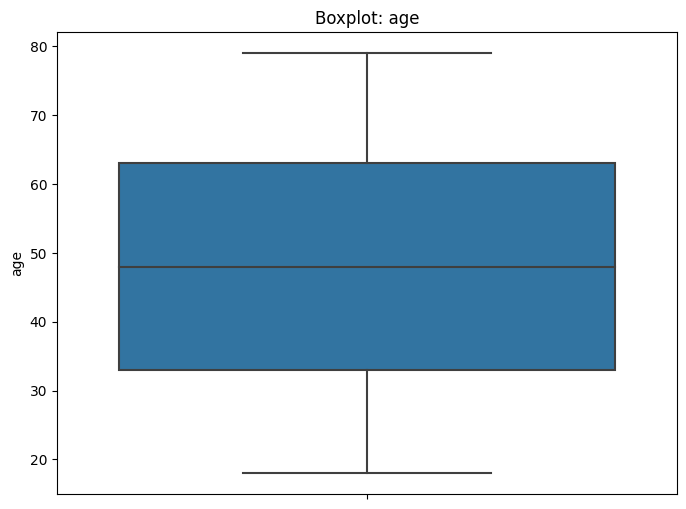

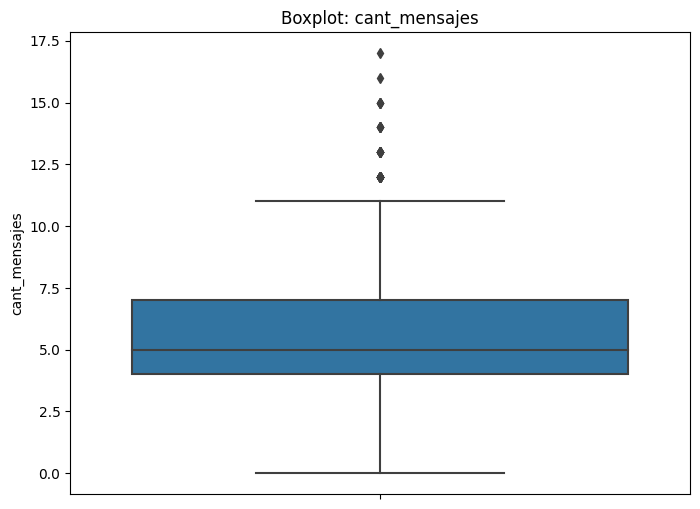

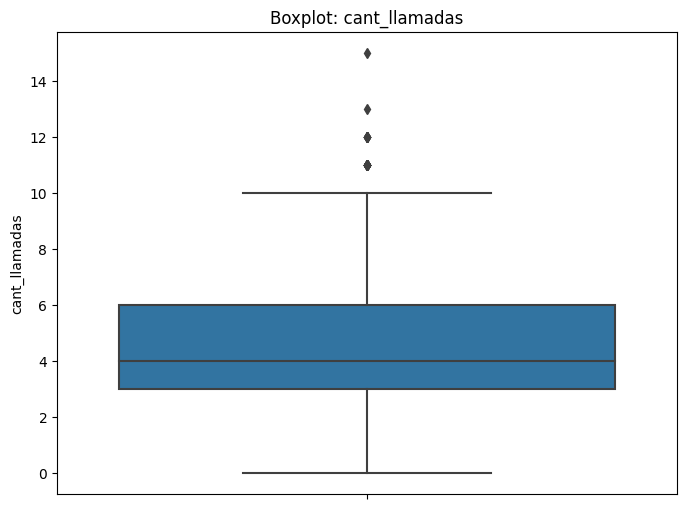

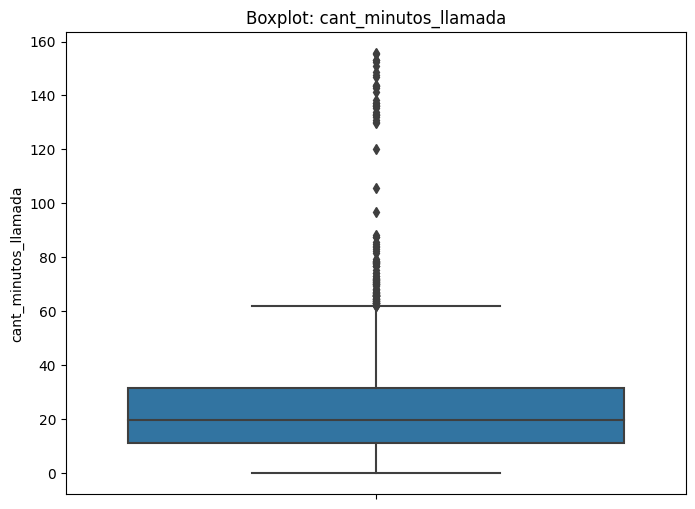

In [92]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 6))           # Crear nueva figura
    sns.boxplot(data=user_profile, y=col)  # Crear boxplot
    plt.title(f'Boxplot: {col}')         # Agregar título
    plt.show()

💡Insights: 

- Age: ...No presenta outliers, un comportamiento totalmente tipico y sin valores atipicos
  
- cant_mensajes: ... se mantiene un comportamiento tipico con unos cuantos valores atipicos de personas que mandan mas mensajes que el promedio, nada relevante realmente.
  
- cant_llamadas: ...Mismo  caso que en la cantidad de mensajes hay un patron predecible y uniforme concentrado en valores tipicos, presentando unos cuants casos de usuarios que hacen mas llamadas que el promedio tipico pero tampoco nada del otro mundo.
  
- cant_minutos_llamada: ... Aqui asi como en los dos casos anteriores existe un comportamiento normal de los usuarios presentando un grupo ligeramente mas numeroso de usuarios que se extienden demasiado en los minutos de llamada y lo mas relevante es hacer enfasis que de ese total de usuarios que tienen un comportamiento atipico se subdividen en dos grupos mas, un grupo que atipicamente habla mas tiempo de lo habitual entre 60 y 100 minutos promedio y el segundo grupo que se extiende de dos horas hasta casi tres, marcando un hueco de personas enmedio que no es comun mantengan esa duracion de sus llamadas, es interesante.

#Resumen ejecutivo de outliers:

- Age: Sin outliers - comportamiento típico

- Mensajes: Pocos outliers superiores - usuarios con alto envío de mensajes

- Llamadas: Pocos outliers superiores - usuarios con alta frecuencia de llamadas  

- Minutos: Outliers más significativos - dos grupos extremos:
* Grupo 1: 60-100 minutos (usuarios de llamadas largas)
* Grupo 2: 120-180 minutos (usuarios de llamadas muy largas)

In [93]:

# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_superiores = (user_profile[col] > limite_superior).sum()
    outliers_inferiores = (user_profile[col] < limite_inferior).sum()
    
    print(f"\n=== {col.upper()} ===")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers superiores: {outliers_superiores}")
    print(f"Outliers inferiores: {outliers_inferiores}")
    print(f"Valor máximo en datos: {user_profile[col].max():.2f}")



=== CANT_MENSAJES ===
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Outliers superiores: 46
Outliers inferiores: 0
Valor máximo en datos: 17.00

=== CANT_LLAMADAS ===
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Outliers superiores: 30
Outliers inferiores: 0
Valor máximo en datos: 15.00

=== CANT_MINUTOS_LLAMADA ===
Q1: 11.12
Q3: 31.41
IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Outliers superiores: 109
Outliers inferiores: 0
Valor máximo en datos: 155.69


In [94]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
 - Si totalmente mantenerlos ya que son datos que muestran un potencial cliente que podria buscar un upgrade para mejorar sus prestaciones de mensajeria en un futuro cercano.
  
- cant_llamadas: mantener o no outliers, porqué?
- Tambien hay que mantener esos outliers pues como el caso anterior, hay una alta posobilidad de ascender a los usuarios que hablan mas de lo usual hacia un plan premium y aquellos que ya lo son, poder mejorar sus beneficios para incentivarlos a no limitarse si necesitan llamar mas tiempo en meses posteriores.
  
- cant_minutos_llamada: mantener o no outliers, porqué?
- Bueno, esta respuesta tambien coincide con mis dos respuestas pasadas de mantener estos datos para monitorear y buscar como cuidar a este nicho de usuarios que muestran una alta demanda de los minutos en llamada con una alta posibilidad de aceptar tener un plan personalizado para que exploten mas los beneficios que ya tienen sin que haya riesgo de que exedan sus beneficios actuales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [95]:
# Crear columna grupo_uso
# Patrón 1: Muchos mensajes + pocas llamadas
user_profile['patron_1'] = np.where(
    (user_profile['cant_mensajes'] > 11.5) & 
    (user_profile['cant_llamadas'] < 5), 
    'Mensajeros_Intensivos', 
    'Otros'
)


In [96]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,patron_1
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Otros
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Otros
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Otros
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Otros
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Otros


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [102]:

# Creando la columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [103]:
# verificar cambios
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

=== DISTRIBUCIÓN GRUPO_USO ===
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

=== DISTRIBUCIÓN GRUPO_EDAD ===
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


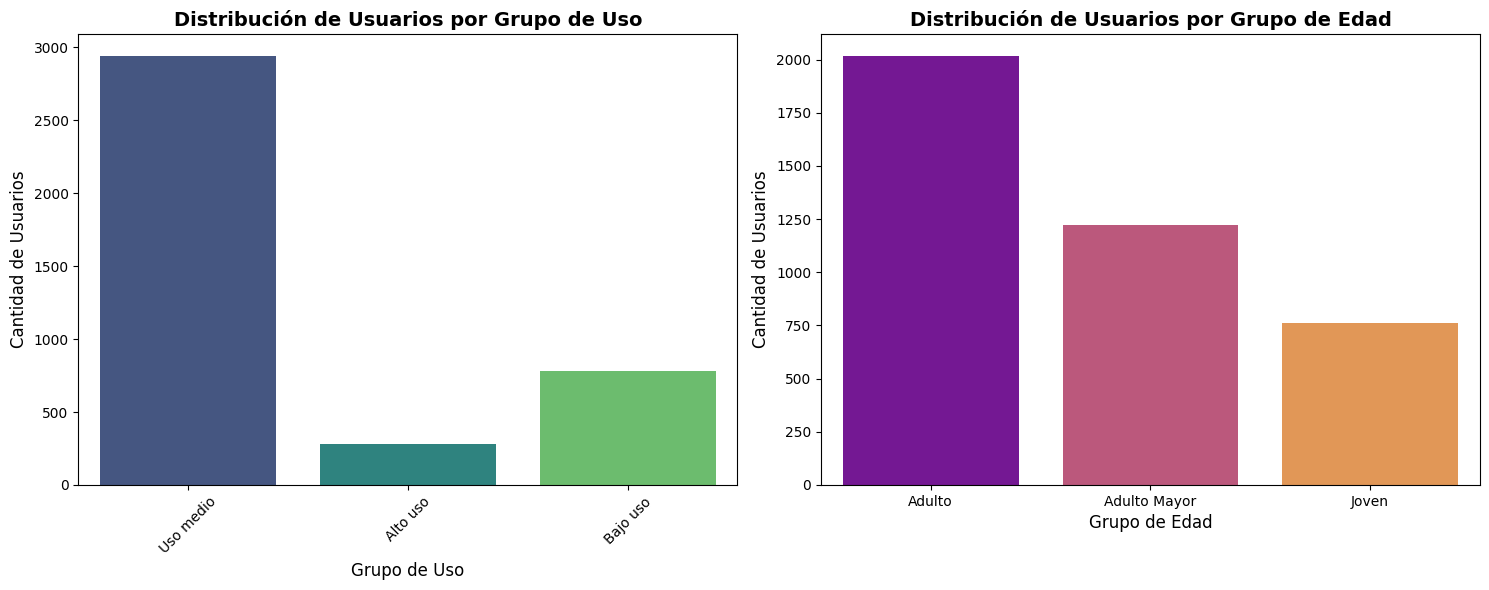

In [105]:
# Crear columna grupo_uso basada en llamadas y mensajes
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

# Verificar la distribución de grupo_uso
print("=== DISTRIBUCIÓN GRUPO_USO ===")
print(user_profile['grupo_uso'].value_counts())
print("\n=== DISTRIBUCIÓN GRUPO_EDAD ===")
print(user_profile['grupo_edad'].value_counts())
# Configurar el estilo de los gráficos
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribución por grupo de uso
sns.countplot(data=user_profile, x='grupo_uso', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Usuarios por Grupo de Uso', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupo de Uso', fontsize=12)
axes[0].set_ylabel('Cantidad de Usuarios', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Distribución por grupo de edad
sns.countplot(data=user_profile, x='grupo_edad', ax=axes[1], palette='plasma')
axes[1].set_title('Distribución de Usuarios por Grupo de Edad', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupo de Edad', fontsize=12)
axes[1].set_ylabel('Cantidad de Usuarios', fontsize=12)

# Ajustar el layout
plt.tight_layout()
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En general mantenian una coherencia, confianza y consistencia solida sin embargo habia ciertas columnas de los data sets "Usuarios" y "Usabilidad" que presentaban datos NaN como -999 en las edades de usuarios no registrados, por mencionar uno.
- Tambien se presentaban datos que eran errores por el diseño del tipo de dato en este caso en las columnas de "length" medir tamaño de mensajes el cual era un NaN en filas de llamadas y de manera contraria presentaba NaN en "duration" que no aplicaba para filas donde se hablaba de un mensaje de texto.


🔍 **Segmentos por Edad**
- Se dividio el total de usuarios en tres grupos concretos, los jovenes menores de 30 años, los adultos para usuarios entre 30 y 60 años y los adultos mayores que se encuentran de 60 años en adelante.
- La gran mayoria de usuarios se encuentra en un rango de edades joven y adultos, marcando una disminucion notable a partir de usuarios que tienen mas de 55 años en promedio.


📊 **Segmentos por Nivel de Uso**
- La mayor cantidad de usuarios activos se encontraron entre los primeros dos grupos pero marcando una diferencia en el tipo de planes que contratan donde es notable que los mas jovenes mantienen un 50/50 de variacion entre ambos planes pero considerablemente se inclina a usuarios premium los usuarios de mas edad como los adultos mayores los cuales tambien tienen una tendencia marcada a llamar mas que mensajear por SMS.
- Existen grupos de usuarios que tienden a llamar mas que a textear y a su vez extenderse en las llamadas mas de una hora lo cual representa un nicho de oportunidad para atacar esos insigths como oportunidades de venderles un plan personalizado de llamadas que aproveche el uso atipico de el telefono sobre el comportamiento tipico de la mayoria de los demas usuarios.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Identificamos usuarios con patrones de uso extremo que representan oportunidades de segmentación y planes premium especializados"
  

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`